<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/Hirusha/mobileNetV2_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# SE4050 Deep Learning Assignment - MobileNetV2 Implementation
# Team Member: Sumanaweera A D H R
# Model: MobileNetV2 for Waste Classification
# Dataset: Waste Classification Data (Organic vs Recyclable)
# =============================================================================

# Import  libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os
from datetime import datetime

In [ ]:
!apt-get install p7zip-full


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import os

seven_z_path = '/content/drive/MyDrive/DATASET.7z'
extract_dir = '/content/DATASET'

# Create extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Extract using 7z command
!7z x "{seven_z_path}" -o"{extract_dir}" -y
print(f"7z file extracted to: {extract_dir}")

# =============================================================================
# DATA PREPARATION AND LOADING
# =============================================================================
train_dir = os.path.join(extract_dir, 'TRAIN')
test_dir = os.path.join(extract_dir, 'TEST')

print("Training directory:", train_dir)
print("Test directory:", test_dir)

# Function to count images in 'organic(O)' and 'recyclable(R)' folders
def count_images(directory):
    organic_count = len(os.listdir(os.path.join(directory, 'O')))
    recyclable_count = len(os.listdir(os.path.join(directory, 'R')))
    return organic_count, recyclable_count

# Count and print the number of images
try:
    train_organic, train_recyclable = count_images(train_dir)
    test_organic, test_recyclable = count_images(test_dir)

    print(f"\nTraining Data: {train_organic} organic, {train_recyclable} recyclable")
    print(f"Test Data: {test_organic} organic, {test_recyclable} recyclable")
    print(f"Total Images: {train_organic + train_recyclable + test_organic + test_recyclable}")

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please check your dataset paths and folder structure!")



7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/                                 1 file, 216000968 bytes (206 MiB)

Extracting archive: /content/drive/MyDrive/DATASET.7z
--
Path = /content/drive/MyDrive/DATASET.7z
Type = 7z
Physical Size = 216000968
Headers Size = 305148
Method = LZMA:23
Solid = +
Blocks = 1

  0%      1%      2% 421 - DATASET/TEST/O/O_12988.jpg                                       3% 422 - DATASET/TEST/O/O_12989.jpg                                       4% 794 - DATASET/TEST/O/O_13361.jpg     

In [ ]:
# =============================================================================
#  DATA PREPROCESSING AND AUGMENTATION
# =============================================================================

# Image parameters for MobileNetV2
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
NUM_CLASSES = 2

# Data Augmentation for Training

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2],
    shear_range=0.2,
    zoom_range=0.25,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=42
)

# Get class indices and labels
class_names = list(train_generator.class_indices.keys())
print(f" Class names: {class_names}")
print(f" Class indices: {train_generator.class_indices}")

Found 22564 images belonging to 2 classes.
Found 2514 images belonging to 2 classes.
 Class names: ['O', 'R']
 Class indices: {'O': 0, 'R': 1}


In [ ]:
# =============================================================================
# MOBILENETV2 MODEL ARCHITECTURE (IMPROVED VERSION)
# =============================================================================

# Load pre-trained MobileNetV2 without top layers
base_model = MobileNetV2(
    weights='imagenet',           # Use pre-trained ImageNet weights
    include_top=False,            # Exclude classification head
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# Freeze base model layers initially (Feature extraction phase)
base_model.trainable = False

print(f" Base Model: MobileNetV2")
print(f" Base model layers frozen: {len([layer for layer in base_model.layers if not layer.trainable])} layers")

# =============================================================================
# ADD CUSTOM CLASSIFICATION HEAD
# =============================================================================
inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Use base model as feature extractor
x = base_model(inputs, training=False)

# Global Average Pooling instead of Flatten
# - Reduces number of parameters
# - Helps prevent overfitting
x = GlobalAveragePooling2D()(x)

# Normalize activations to stabilize training
x = BatchNormalization()(x)

# =============================================================================
# FULLY CONNECTED (DENSE) LAYERS WITH REGULARIZATION AND DROPOUT
# =============================================================================
# Stronger regularization + slightly higher dropout to reduce overfitting
# Increased L2 penalty from 0.001 -> 0.002 and Dropout from 0.4 -> 0.5

x = Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)   # Increased dropout for better generalization

# Second Dense layer with L2 regularization and slightly higher dropout
x = Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

# Output layer with softmax activation for class probabilities
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# =============================================================================
# DEFINE FINAL MODEL
# =============================================================================
model = Model(inputs, outputs)

print("  Model architecture created successfully!")
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 Base Model: MobileNetV2
 Base model layers frozen: 154 layers
  Model architecture created successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,730 (10.02 MB)

 Trainable params: 364,418 (1.39 MB)

 Non-trainable params: 2,261,312 (8.63 MB)

In [ ]:
# =============================================================================
# MODEL COMPILATION
# =============================================================================

model.compile(optimizer=Adam(learning_rate=0.0005),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()])

model.summary()
print(" Model compiled successfully!")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,730 (10.02 MB)

 Trainable params: 364,418 (1.39 MB)

 Non-trainable params: 2,261,312 (8.63 MB)

 Model compiled successfully!


In [ ]:
# =============================================================================
# CALLBACKS SETUP
# =============================================================================

callbacks = [
    # -------------------------------------------------------------------------
    # Reduce learning rate when validation loss stops improving
    # Helps the model converge smoothly by lowering LR on plateaus
    # -------------------------------------------------------------------------
    ReduceLROnPlateau(
        monitor='val_loss',     # Track validation loss for plateau detection
        factor=0.3,             # Reduce LR by 70%
        patience=4,             # Wait 4 epochs before reducing LR
        min_lr=1e-7,            # Minimum LR limit
        verbose=1
    ),

    # -------------------------------------------------------------------------
    # Early stopping to prevent overfitting
    # Stops training if val_loss doesn’t improve for 'patience' epochs
    # -------------------------------------------------------------------------
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,             # Slightly higher patience for smoother convergence
        restore_best_weights=True,  # Revert to best weights after stopping
        verbose=1
    ),

    # -------------------------------------------------------------------------
    # Model checkpoint to save the best model during training
    # Saves model only when validation accuracy improves
    # -------------------------------------------------------------------------
    ModelCheckpoint(
        'best_mobilenetv2_model.h5',
        monitor='val_accuracy',
        save_best_only=True,    # Save only the best-performing model
        mode='max',
        verbose=1
    )
]

print(" Callbacks configured successfully!")


 Callbacks configured successfully!


In [ ]:
# =============================================================================
# INITIAL TRAINING (FEATURE EXTRACTION)
# =============================================================================

print("\n  Initial Training - Feature Extraction Phase")
print(" Training only the custom head, base model frozen")

# Calculate steps per epoch
train_steps = train_generator.samples // BATCH_SIZE
val_steps = test_generator.samples // BATCH_SIZE

print(f" Training steps per epoch: {train_steps}")
print(f" Validation steps per epoch: {val_steps}")

# Initial training with frozen base model
print(" Starting initial training.")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=callbacks,
    verbose=1,
    shuffle=True,
)

print(" Initial training completed!")



  Initial Training - Feature Extraction Phase
 Training only the custom head, base model frozen
 Training steps per epoch: 705
 Validation steps per epoch: 78
 Starting initial training.
Epoch 1/15
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8618 - loss: 1.5500 - precision: 0.8618 - recall: 0.8618
Epoch 1: val_accuracy improved from -inf to 0.86158, saving model to best_mobilenetv2_model.h5


706/706 ━━━━━━━━━━━━━━━━━━━━ 337s 477ms/step - accuracy: 0.8619 - loss: 1.5498 - precision: 0.8619 - recall: 0.8619 - val_accuracy: 0.8616 - val_loss: 1.1982 - val_precision: 0.8616 - val_recall: 0.8616 - learning_rate: 5.0000e-04
Epoch 2/15
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9074 - loss: 1.0719 - precision: 0.9074 - recall: 0.9074
Epoch 2: val_accuracy did not improve from 0.86158
706/706 ━━━━━━━━━━━━━━━━━━━━ 302s 428ms/step - accuracy: 0.9074 - loss: 1.0718 - precision: 0.9074 - recall: 0.9074 - val_accuracy: 0.8413 - val_loss: 0.8698 - val_precision: 0.8413 - val_recall: 0.8413 - learning_rate: 5.0000e-04
Epoch 3/15
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9210 - loss: 0.7349 - precision: 0.9210 - recall: 0.9210
Epoch 3: val_accuracy did not improve from 0.86158
706/706 ━━━━━━━━━━━━━━━━━━━━ 304s 431ms/step - accuracy: 0.9210 - loss: 0.7348 - precision: 0.9210 - recall: 0.9210 - val_accuracy: 0.8417 - val_loss: 0.6691 - val_precision: 0.8417 - va

706/706 ━━━━━━━━━━━━━━━━━━━━ 302s 427ms/step - accuracy: 0.9231 - loss: 0.4258 - precision: 0.9231 - recall: 0.9231 - val_accuracy: 0.8946 - val_loss: 0.4502 - val_precision: 0.8946 - val_recall: 0.8946 - learning_rate: 5.0000e-04
Epoch 7/15
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9256 - loss: 0.4073 - precision: 0.9256 - recall: 0.9256
Epoch 7: val_accuracy did not improve from 0.89459
706/706 ━━━━━━━━━━━━━━━━━━━━ 305s 432ms/step - accuracy: 0.9256 - loss: 0.4073 - precision: 0.9256 - recall: 0.9256 - val_accuracy: 0.8123 - val_loss: 0.5505 - val_precision: 0.8123 - val_recall: 0.8123 - learning_rate: 5.0000e-04
Epoch 8/15
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9264 - loss: 0.4099 - precision: 0.9264 - recall: 0.9264
Epoch 8: val_accuracy did not improve from 0.89459
706/706 ━━━━━━━━━━━━━━━━━━━━ 302s 427ms/step - accuracy: 0.9264 - loss: 0.4099 - precision: 0.9264 - recall: 0.9264 - val_accuracy: 0.8544 - val_loss: 0.4880 - val_precision: 0.8544 - va

In [ ]:
# =============================================================================
# Fine-Tuning Phase (Optimized for Stability & Performance)
# =============================================================================

base_model.trainable = True

# Unfreeze last 30% of layers for fine-tuning
fine_tune_at = int(len(base_model.layers) * 0.7)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f"\nFine-tuning setup:")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   Frozen layers: {fine_tune_at}")
print(f"   Trainable layers: {len(base_model.layers) - fine_tune_at}")

# Optimizer with smaller learning rate for stable fine-tuning
optimizer = keras.optimizers.Adam(
    learning_rate=1e-5,
    weight_decay=1e-6
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)


def cosine_decay(epoch, lr):
    max_epochs = 25  # fine-tuning phase only
    return 0.5 * lr * (1 + np.cos(np.pi * epoch / max_epochs))

lr_scheduler = keras.callbacks.LearningRateScheduler(cosine_decay, verbose=1)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        'best_mobilenetv2_finetuned.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    lr_scheduler
]

train_steps = len(train_generator)
val_steps = len(test_generator)

print(f"\nStarting fine-tuning phase...")
print(f"   Steps per epoch (train): {train_steps}")
print(f"   Steps per epoch (validation): {val_steps}")

fine_tune_epochs = 25
initial_epoch = len(history.epoch)
total_epochs = initial_epoch + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=initial_epoch,
    steps_per_epoch=train_steps,
    validation_data=test_generator,
    validation_steps=val_steps,
    callbacks=callbacks,
    verbose=1
)

print("\n Fine-tuning completed successfully!")



Fine-tuning setup:
   Total layers: 154
   Frozen layers: 107
   Trainable layers: 47

Starting fine-tuning phase...
   Steps per epoch (train): 706
   Steps per epoch (validation): 79

Epoch 14: LearningRateScheduler setting learning rate to 4.686047283973919e-06.
Epoch 14/38
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9265 - loss: 0.2878 - precision_5: 0.9265 - recall_5: 0.9265
Epoch 14: val_accuracy improved from -inf to 0.87828, saving model to best_mobilenetv2_finetuned.keras
706/706 ━━━━━━━━━━━━━━━━━━━━ 369s 486ms/step - accuracy: 0.9265 - loss: 0.2878 - precision_5: 0.9265 - recall_5: 0.9265 - val_accuracy: 0.8783 - val_loss: 0.3648 - val_precision_5: 0.8783 - val_recall_5: 0.8783 - learning_rate: 4.6860e-06

Epoch 15: LearningRateScheduler setting learning rate to 1.9039848003314978e-06.
Epoch 15/38
706/706 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9328 - loss: 0.2709 - precision_5: 0.9328 - recall_5: 0.9328
Epoch 15: val_accuracy improved from 0.87828 to 0

In [ ]:
# =============================================================================
#  MODEL EVALUATION
# =============================================================================

# Load the best saved model
best_model = keras.models.load_model('best_mobilenetv2_model.h5',compile=True)

# Evaluate on test data
print(" Evaluating model on test data...")
test_loss, test_accuracy, test_precision, test_recall = best_model.evaluate(test_generator)
print(f" Test Accuracy: {test_accuracy:.4f}")



 Evaluating model on test data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 0.9383 - loss: 0.3898 - precision: 0.9383 - recall: 0.9383
 Test Accuracy: 0.8946


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load the fine-tuned model
best_model = keras.models.load_model('best_mobilenetv2_finetuned.keras', compile=False)

# Predict classes
y_pred = best_model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Class names (should match your dataset folders)
class_labels = list(test_generator.class_indices.keys())

# Print classification report
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels, digits=4))

# Optional: Confusion matrix
print("\n🔍 Confusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))


79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 94ms/step

📊 Classification Report:
              precision    recall  f1-score   support

           O     0.8536    0.9686    0.9075      1402
           R     0.9523    0.7905    0.8639      1112

    accuracy                         0.8898      2514
   macro avg     0.9029    0.8795    0.8857      2514
weighted avg     0.8972    0.8898    0.8882      2514


🔍 Confusion Matrix:
[[1358   44]
 [ 233  879]]


79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 101ms/step

Classification Report:
              precision    recall  f1-score   support

           O       0.86      0.97      0.91      1402
           R       0.95      0.81      0.87      1112

    accuracy                           0.89      2514
   macro avg       0.91      0.89      0.89      2514
weighted avg       0.90      0.89      0.89      2514



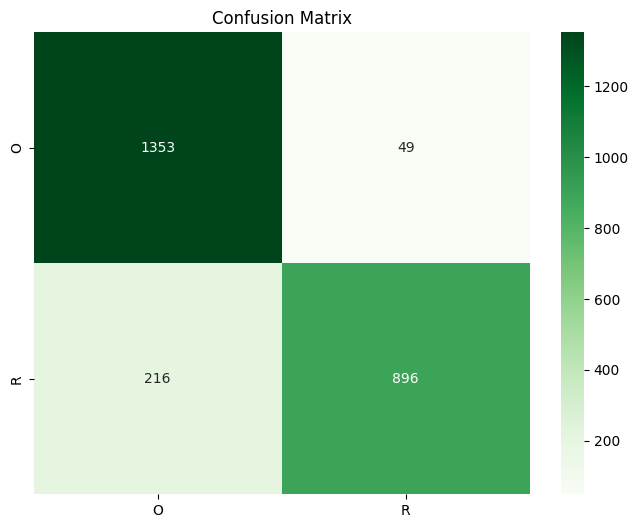

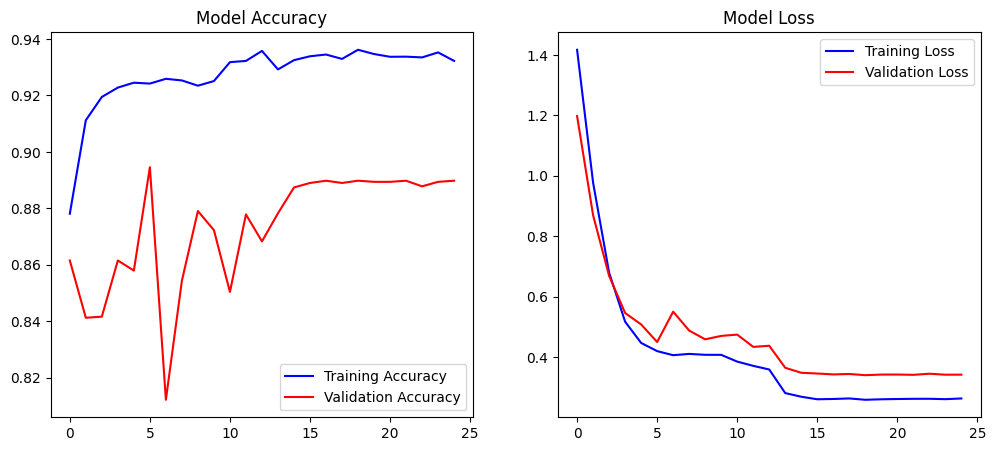

In [ ]:
# CONFUSION MATRIX & REPORT
# =============================================================================
test_generator.reset()
preds = best_model.predict(test_generator)
pred_classes = np.argmax(preds, axis=1)
true_classes = test_generator.classes

print("\nClassification Report:")
print(classification_report(true_classes, pred_classes, target_names=class_names))

cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.show()

# =============================================================================
# PLOTTING
# =============================================================================
def plot_metrics(history1, history2=None):
    acc = history1.history['accuracy'] + (history2.history['accuracy'] if history2 else [])
    val_acc = history1.history['val_accuracy'] + (history2.history['val_accuracy'] if history2 else [])
    loss = history1.history['loss'] + (history2.history['loss'] if history2 else [])
    val_loss = history1.history['val_loss'] + (history2.history['val_loss'] if history2 else [])

    epochs = range(len(acc))
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Model Loss')
    plt.legend()
    plt.show()

plot_metrics(history, history_fine)

In [ ]:
# =============================================================================
# MODEL SAVING AND SUMMARY
# =============================================================================

# Save the final model
model.save('final_mobilenetv2_waste_classifier.h5')
print(" Final model saved as 'final_mobilenetv2_waste_classifier.h5'")

# Model summary
print("\n" + "="*50)
print(" MOBILENETV2 IMPLEMENTATION SUMMARY")
print("="*50)
print(f" Dataset: Waste Classification (Organic vs Recyclable)")
print(f" Input Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f" Classes: {class_names}")
print(f" Test Accuracy: {test_accuracy:.4f}")
print(f" Test Precision: {test_precision:.4f}")
print(f" Test Recall: {test_recall:.4f}")
print(f" Model Size: {os.path.getsize('final_mobilenetv2_waste_classifier.h5') / (1024*1024):.2f} MB")
print("="*50)

print("\n MobileNetV2 Implementation Completed Successfully!")

 Final model saved as 'final_mobilenetv2_waste_classifier.h5'

 MOBILENETV2 IMPLEMENTATION SUMMARY
 Dataset: Waste Classification (Organic vs Recyclable)
 Input Size: 224x224
 Classes: ['O', 'R']
 Test Accuracy: 0.8946
 Test Precision: 0.8946
 Test Recall: 0.8946
 Model Size: 26.95 MB

 MobileNetV2 Implementation Completed Successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


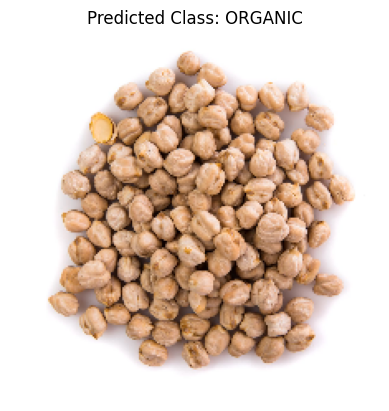

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load and preprocess the test image
img_path = "/content/drive/MyDrive/WhatsApp Image 2025-05-03 at 08.38.49_42252bdc.jpg"  # change this path to your image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
pred = model.predict(img_array)
classes = ['ORGANIC', 'RECYCLE']
predicted_class = classes[np.argmax(pred)]

# Display the image with the predicted class
plt.imshow(image.load_img(img_path, target_size=(224, 224)))
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')  # Hide axis for a cleaner look
plt.show()


In [ ]:

from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/final_mobilenetv2_waste_classifier.h5")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


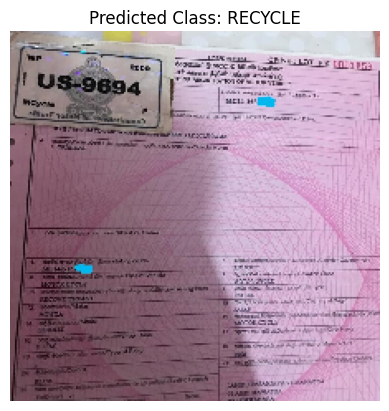

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load and preprocess the test image
img_path = "/content/drive/MyDrive/IMG_20230309_181621.jpg"  # change this path to your image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
pred = model.predict(img_array)
classes = ['ORGANIC', 'RECYCLE']
predicted_class = classes[np.argmax(pred)]

# Display the image with the predicted class
plt.imshow(image.load_img(img_path, target_size=(224, 224)))
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')  # Hide axis for a cleaner look
plt.show()
